In [16]:
import os
import certifi

os.environ['SSL_CERT_FILE'] = certifi.where()

# Now import fetch_openml (after setting SSL_CERT_FILE)
from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

In [11]:
X, y = fetch_openml('mnist_784', version=1,return_X_y=True)
y = y.astype(int)
X = ((X / 255.) - .5) * 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000,random_state=123, stratify=y)

del X, y  # Free up memory

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(128,64),max_iter=20, random_state=42, verbose=True)
mlp.fit(X_train, y_train)

# Time: 2m 2s (layers = 128,64; iter=20)

Iteration 1, loss = 0.42931812
Iteration 2, loss = 0.18899930
Iteration 3, loss = 0.13854660
Iteration 4, loss = 0.11361500
Iteration 5, loss = 0.09425317
Iteration 6, loss = 0.08125062
Iteration 7, loss = 0.07407662
Iteration 8, loss = 0.06498670
Iteration 9, loss = 0.05745681
Iteration 10, loss = 0.05408240
Iteration 11, loss = 0.05351298
Iteration 12, loss = 0.04474100
Iteration 13, loss = 0.03991720
Iteration 14, loss = 0.03531297
Iteration 15, loss = 0.03444531
Iteration 16, loss = 0.03334830
Iteration 17, loss = 0.03223166
Iteration 18, loss = 0.02938789
Iteration 19, loss = 0.02338567
Iteration 20, loss = 0.02344563


/Users/jared.mcbride/Documents/Code Projects/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, random_state=42,
              verbose=True)

In [13]:
s = mlp.score(X_test, y_test)
print(f"Test set accuracy: {s*100:.2f}%")

y_pred = mlp.predict(X_test)
c = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(c)


Test set accuracy: 97.35%
Confusion Matrix:
[[ 975    0    3    1    0    2    3    0    1    1]
 [   0 1120    1    0    0    0    1    2    1    0]
 [   3    2  988    1    0    0    2    1    2    0]
 [   3    1   14  980    0    9    0    4    8    1]
 [   1    3    1    0  943    0    6    8    2   11]
 [   2    1    1   10    1  871    5    2    6    3]
 [   3    2    0    0    0    3  974    0    0    0]
 [   0    3   14    4    2    1    1 1014    2    1]
 [   4    3    9    4    2    5    8    1  937    2]
 [   7    3    5    2    9    7    2   19    7  933]]


In [ ]:
# Now for PCA dimensionality reduction
pca = PCA(n_components=0.95)  # Retain 95% of variance
x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)
x_train_pca.shape

# 154 components retained

(60000, 154)

In [ ]:
mlp_pca = MLPClassifier(hidden_layer_sizes=(128,64), max_iter=20, verbose=True)
mlp_pca.fit(x_train_pca, y_train)

# Time: 53s (layers = 128,64; iter=20; PCA)

Iteration 1, loss = 0.42383657
Iteration 2, loss = 0.13380923
Iteration 3, loss = 0.08781536
Iteration 4, loss = 0.06254662
Iteration 5, loss = 0.04556551
Iteration 6, loss = 0.03362405
Iteration 7, loss = 0.02474583
Iteration 8, loss = 0.01827559
Iteration 9, loss = 0.01330733
Iteration 10, loss = 0.00985193
Iteration 11, loss = 0.00683437
Iteration 12, loss = 0.00487761
Iteration 13, loss = 0.00351109
Iteration 14, loss = 0.00233540
Iteration 15, loss = 0.00168873
Iteration 16, loss = 0.00122433
Iteration 17, loss = 0.00099085
Iteration 18, loss = 0.00080535
Iteration 19, loss = 0.00066400
Iteration 20, loss = 0.00056486


/Users/jared.mcbride/Documents/Code Projects/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=20, verbose=True)

In [26]:
s_pca = mlp_pca.score(x_test_pca, y_test)
print(f"PCA Test set accuracy: {s_pca*100:.2f}%")
print(f"Full Test set accuracy: {s*100:.2f}%")

y_pred = mlp_pca.predict(x_test_pca)
c_pca = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(c_pca)

print(f"Change in Confusion Matrices: C - C_PCA =\n{c - c_pca}")

PCA Test set accuracy: 97.53%
Full Test set accuracy: 97.35%
Confusion Matrix:
[[ 977    0    1    0    0    2    1    1    3    1]
 [   0 1113    2    1    1    2    2    3    0    1]
 [   6    2  981    2    2    0    1    1    3    1]
 [   2    1   12  982    0   11    0    5    6    1]
 [   1    1    2    0  947    0    6    7    2    9]
 [   2    1    1   11    2  876    2    1    3    3]
 [   6    0    3    0    4    7  959    0    3    0]
 [   1    1    6    5    2    0    1 1019    2    5]
 [   4    3    2    5    6    7    1    2  942    3]
 [   1    1    1    3    8    4    2   12    5  957]]
Change in Confusion Matrices: C - C_PCA =
[[ -2   0   2   1   0   0   2  -1  -2   0]
 [  0   7  -1  -1  -1  -2  -1  -1   1  -1]
 [ -3   0   7  -1  -2   0   1   0  -1  -1]
 [  1   0   2  -2   0  -2   0  -1   2   0]
 [  0   2  -1   0  -4   0   0   1   0   2]
 [  0   0   0  -1  -1  -5   3   1   3   0]
 [ -3   2  -3   0  -4  -4  15   0  -3   0]
 [ -1   2   8  -1   0   1   0  -5   0  -4]
 [  

(28, 28)
(28, 28)
(28, 28)
(28, 28)
(28, 28)


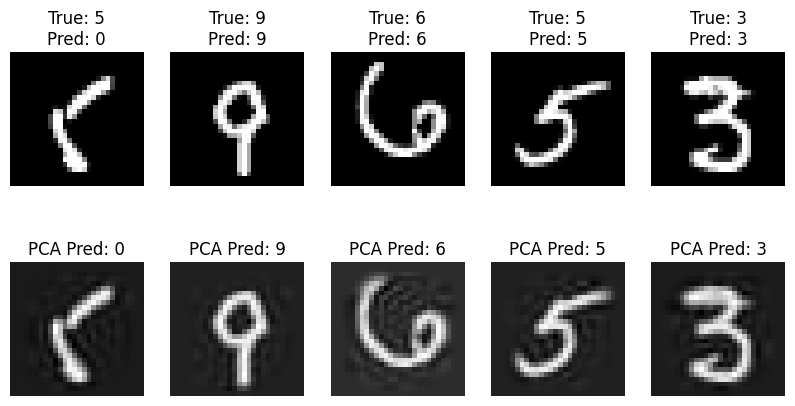

In [ ]:
## Visualize the effrct of the data reduction



fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    mat = X_test.iloc[i].to_numpy().reshape(28, 28)
    axes[0, i].imshow(mat, cmap='gray')
    axes[0, i].set_title(f"True: {y_test.iloc[i]}\nPred: {y_pred[i]}")
    axes[0, i].axis('off')

    recon_img = pca.inverse_transform(x_test_pca[i]).reshape(28, 28)
    axes[1, i].imshow(recon_img.reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f"PCA Pred: {y_pred[i]}")
    axes[1, i].axis('off')